<a href="https://colab.research.google.com/github/anyuanay/info213/blob/main/INFO213_Week6_7_8_Lecture_pipeline_crossV_hyperparameter_tuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# INFO 213: Data Science Programming 2
___

### Week 6-7: Pipeline, Cross Validation, and Hyperparameter Tuning


**Agenda:**
- Pipeline for wrapping up preprocessing and model fitting steps.
- Needs for cross-validation to assess model performance effectively.
- K-Fold Cross-Validation.
- Understanding hyperparameters vs. parameters.
- Grid Search: Exhaustive search over specified hyperparameter values

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Streamlining workflows with pipelines

- Prior to training a model, we may apply a variety of preprocessing techniques on the data, such as standardization for feature scaling.
- We have to reuse the parameters that were obtained during the fitting of the training data to scale and compress any new data.
- scikit-learn provides an extremely handy tool, the `Pipeline`
class that allows us to fit a model including an arbitrary number of transformation steps and apply it to make predictionsabout new data.

## Loading the Breast Cancer Wisconsin dataset
- We will be working with the Breast Cancer Wisconsindataset, which contains 569 examples of malignant and benign tumor cells.
- The first two columns in the dataset store the unique ID
numbers ofthe examples and the corresponding diagnoses (M = malignant, B = benign), respectively.
- Columns 3-32 contain 30 real-valued features thathave been computed from digitized images of the cell nuclei, which canbe used to build a model to predict whether a tumor is benign or malig-nant.

In [ ]:
path_wdbc = "/content/drive/MyDrive/Colab Notebooks/courses/INFO213/lectures/wdbc.data"

df = pd.read_csv(path_wdbc, header=None)

df.head()

,0,1,2,3,4,5,6,7,8,9,...,22,23,24,25,26,27,28,29,30,31
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [ ]:
df.shape

(569, 32)

We will assign the 30 features to a NumPy array, X. Using a
LabelEncoder object, we will transform the class labels from their original string representation ('M' and 'B') into integers:

In [ ]:
from sklearn.preprocessing import LabelEncoder

X = df.loc[:, 2:].values
y = df.loc[:, 1].values
le = LabelEncoder()
y = le.fit_transform(y)
le.classes_

array(['B', 'M'], dtype=object)

- After encoding the class labels (diagnosis) in an array, y, the malignant tumors are now represented as class 1, and the benign tumorsare represented as class 0, respectively.
- We can double-check this mapping by calling the transform method of the fitted LabelEncoder on two dummy class labels:

In [ ]:
le.transform(['M', 'B'])

array([1, 0])

Divide the dataset into a separate training dataset (80 percentof the data) and a separate test dataset (20 percent of the data):

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = \
    train_test_split(X, y,
                     test_size=0.20,
                     stratify=y,
                     random_state=1)

## Combining transformers and estimators in a pipeline
- We will standardize the columns in the Breast Cancer
Wisconsin dataset before we feed them to a linear classifier, such as logistic regression.
- We want to compress our data from the initial 30 dimensions onto a lower two-dimensional subspace via principal component analysis (PCA), a feature extraction technique for dimensionality reduction.
- We can chain the StandardScaler, PCA, and LogisticRegression
objects in a pipeline:

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline

pipe_lr = make_pipeline(StandardScaler(),
                        PCA(n_components=2),
                        LogisticRegression(random_state=1, solver='lbfgs'))

pipe_lr.fit(X_train, y_train)
y_pred = pipe_lr.predict(X_test)
print('Test Accuracy: %.3f' % pipe_lr.score(X_test, y_test))

Test Accuracy: 0.956


The pipelines of the scikit-learn library are immensely useful wrapper tools. To make sure that you've got a good grasp of how the Pipeline object works, please take a close look at the following illustration:
<img src="https://i.imgur.com/1vxItHg.png" width = 800>

# Using k-fold cross validation to assess model performance

## The heldout method
- We split our initial dataset into separate training and test datasets—the former is used for model training, and the latter is used to estimate its generalization performance.
- Using the test set for tuning parameters, model selection, will be more likely to overfit.
- A holdout method for model selection is to separate the data into three parts: a training dataset, a validation dataset, anda test dataset.
<img src="https://i.imgur.com/t6Nyb0t.png" width=800>

## K-fold cross-validation
- A disadvantage of the holdout method is that the performance estimate may be very sensitive to how we
partition the training dataset into the training and validation subsets.
- A more robust technique for performance estimation is k-fold cross-validation, where we repeat the holdout method k times on k subsets of the training data.

<img src="https://i.imgur.com/DfOfyn8.png" width=800>

### Stratified K-Fold
- A slight improvement over the standard k-fold cross-validation approach is stratified k-fold cross-validation.
- In stratified cross-validation, the class label proportions
are preserved in each fold to ensure that each fold is representative of the class proportions in the training dataset.

In [ ]:
import numpy as np
from sklearn.model_selection import StratifiedKFold


kfold = StratifiedKFold(n_splits=10).split(X_train, y_train)

scores = []
for k, (train, test) in enumerate(kfold):
    pipe_lr.fit(X_train[train], y_train[train])
    score = pipe_lr.score(X_train[test], y_train[test])
    scores.append(score)
    print('Fold: %2d, Class dist.: %s, Acc: %.3f' % (k+1,
          np.bincount(y_train[train]), score))

print('\nCV accuracy: %.3f +/- %.3f' % (np.mean(scores), np.std(scores)))

Fold:  1, Class dist.: [256 153], Acc: 0.935
Fold:  2, Class dist.: [256 153], Acc: 0.935
Fold:  3, Class dist.: [256 153], Acc: 0.957
Fold:  4, Class dist.: [256 153], Acc: 0.957
Fold:  5, Class dist.: [256 153], Acc: 0.935
Fold:  6, Class dist.: [257 153], Acc: 0.956
Fold:  7, Class dist.: [257 153], Acc: 0.978
Fold:  8, Class dist.: [257 153], Acc: 0.933
Fold:  9, Class dist.: [257 153], Acc: 0.956
Fold: 10, Class dist.: [257 153], Acc: 0.956

CV accuracy: 0.950 +/- 0.014


scikit-learn also implements a k-fold cross-validation scorer, which allows us to evaluate our model using stratified k-fold cross-validation less verbosely:

In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(estimator=pipe_lr,
                         X=X_train,
                         y=y_train,
                         cv=10,
                         n_jobs=1)
print('CV accuracy scores: %s' % scores)
print('CV accuracy: %.3f +/- %.3f' % (np.mean(scores), np.std(scores)))

CV accuracy scores: [0.93478261 0.93478261 0.95652174 0.95652174 0.93478261 0.95555556
 0.97777778 0.93333333 0.95555556 0.95555556]
CV accuracy: 0.950 +/- 0.014


# Debugging algorithms with learning curves

- Two very simple yet powerful diagnostic tools that can help us to improve the performance of a learning algorithm: learning curves and validation curves.

## Diagnosing bias and variance problems with learning curves
<img src="https://i.imgur.com/zWLPRXO.png" width=800>

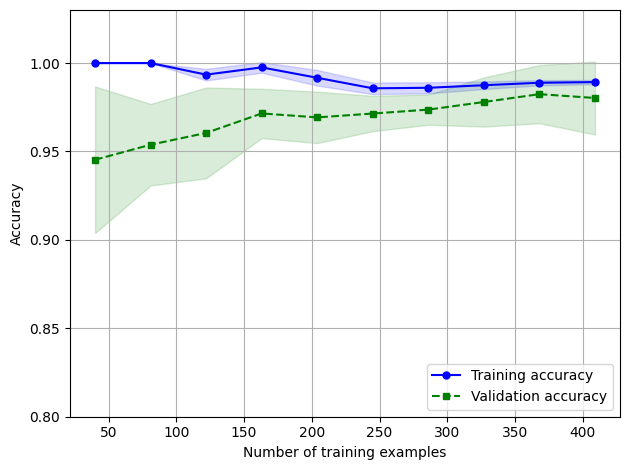

In [ ]:
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve


pipe_lr = make_pipeline(StandardScaler(),
                        LogisticRegression(penalty='l2', random_state=1,
                                           solver='lbfgs', max_iter=10000))

train_sizes, train_scores, test_scores =\
                learning_curve(estimator=pipe_lr,
                               X=X_train,
                               y=y_train,
                               train_sizes=np.linspace(0.1, 1.0, 10),
                               cv=10,
                               n_jobs=1)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.plot(train_sizes, train_mean,
         color='blue', marker='o',
         markersize=5, label='Training accuracy')

plt.fill_between(train_sizes,
                 train_mean + train_std,
                 train_mean - train_std,
                 alpha=0.15, color='blue')

plt.plot(train_sizes, test_mean,
         color='green', linestyle='--',
         marker='s', markersize=5,
         label='Validation accuracy')

plt.fill_between(train_sizes,
                 test_mean + test_std,
                 test_mean - test_std,
                 alpha=0.15, color='green')

plt.grid()
plt.xlabel('Number of training examples')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.ylim([0.8, 1.03])
plt.tight_layout()
# plt.savefig('images/06_05.png', dpi=300)
plt.show()

<br>
<br>

## Addressing over- and underfitting with validation curves

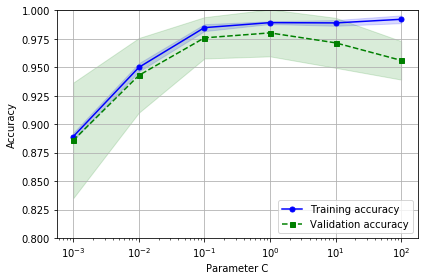

In [ ]:
from sklearn.model_selection import validation_curve


param_range = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
train_scores, test_scores = validation_curve(
                estimator=pipe_lr,
                X=X_train,
                y=y_train,
                param_name='logisticregression__C',
                param_range=param_range,
                cv=10)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.plot(param_range, train_mean,
         color='blue', marker='o',
         markersize=5, label='Training accuracy')

plt.fill_between(param_range, train_mean + train_std,
                 train_mean - train_std, alpha=0.15,
                 color='blue')

plt.plot(param_range, test_mean,
         color='green', linestyle='--',
         marker='s', markersize=5,
         label='Validation accuracy')

plt.fill_between(param_range,
                 test_mean + test_std,
                 test_mean - test_std,
                 alpha=0.15, color='green')

plt.grid()
plt.xscale('log')
plt.legend(loc='lower right')
plt.xlabel('Parameter C')
plt.ylabel('Accuracy')
plt.ylim([0.8, 1.0])
plt.tight_layout()
# plt.savefig('images/06_06.png', dpi=300)
plt.show()

# Fine-tuning machine learning models via grid search
- There two types of parameters: those that are learned from the training data, for
example, the weights in logistic regression, and the parameters of a learning algorithm that are optimized separately.
- The latter are the tuning parameters (or hyperparameters) of a model, for example, the regularization parameter in logistic regression or the depth parameter of a decision tree.
- Grid search is a popular hyperparameter optimization
technique.

## Tuning hyperparameters via grid search
- It's a brute-force exhaustive search paradigm.
- We specify a list of values for different
hyperparameters.
- The computer evaluates the model performance for each combination to obtain the optimal combination of values from this set.

In [ ]:
from sklearn.model_selection import GridSearchCV

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline

pipe_lr = make_pipeline(StandardScaler(),
                        PCA(n_components=2),
                        LogisticRegression(random_state=1))

param_range = [0.01, 0.1, 1.0, 10.0, 100.0]

param_grid = {'logisticregression__C': param_range, 'logisticregression__solver': ('lbfgs', 'liblinear')}

gs = GridSearchCV(estimator=pipe_lr,
                  param_grid=param_grid,
                  scoring='accuracy',
                  refit=True,
                  cv=10,
                  n_jobs=-1)

gs = gs.fit(X_train, y_train)

print(gs.best_score_)
print(gs.best_params_)

0.9495169082125603
{'logisticregression__C': 1.0, 'logisticregression__solver': 'lbfgs'}


In [ ]:
clf = gs.best_estimator_

# clf.fit(X_train, y_train)
# note that we do not need to refit the classifier
# because this is done automatically via refit=True.

print('Test accuracy: %.3f' % clf.score(X_test, y_test))

Test accuracy: 0.956


## Algorithm selection with nested cross-validation
- In nested cross-validation, we have an outer k-fold cross-validation loop to split the data into training and test folds.
- An inner loop is used to select the model using k-fold cross-validation on the training fold.
- After model selection, the test fold is then used to evaluate the model performance.
<img src="https://i.imgur.com/6ny8VBz.png" width=800>

In [ ]:
gs = GridSearchCV(estimator=pipe_lr,
                  param_grid=param_grid,
                  scoring='accuracy',
                  cv=2)

scores = cross_val_score(gs, X_train, y_train,
                         scoring='accuracy', cv=5)
print('CV accuracy: %.3f +/- %.3f' % (np.mean(scores),
                                      np.std(scores)))

CV accuracy: 0.941 +/- 0.016


We can use the nested cross-validation approach to compare a logistic regression model to a simple decision tree classifier:

In [ ]:
from sklearn.tree import DecisionTreeClassifier

gs = GridSearchCV(estimator=DecisionTreeClassifier(random_state=0),
                  param_grid=[{'max_depth': [1, 2, 3, 4, 5, 6, 7, None]}],
                  scoring='accuracy',
                  cv=2)

scores = cross_val_score(gs, X_train, y_train,
                         scoring='accuracy', cv=5)
print('CV accuracy: %.3f +/- %.3f' % (np.mean(scores),
                                      np.std(scores)))

CV accuracy: 0.934 +/- 0.016


As we can see, the nested cross-validation performance of the Logist Regression model (94.1 percent) is better than the performance of the decision tree (93.4 percent), and thus, we'd expect that it might be the better choice to classify new data that comes from the same population as this particular dataset.